## Aliartos Simulation 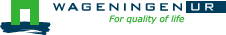

In [1]:
import sys
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import pcse
import numpy as np

print(f"Python version: {sys.version}")
print(f"PCSE version: {pcse.__version__}")

Python version: 3.13.12 | packaged by Anaconda, Inc. | (main, Feb 24 2026, 16:07:20) [Clang 20.1.8 ]
PCSE version: 6.0.12


In [2]:
# Project root
project = Path("/Users/paulianoprescu/Projects/wofost_miscanthus/giganteus")
input_dir = project / "calibration"

crop_file    = input_dir / "crop_params" / "miscanthus_giganteus.yaml"
soil_file    = input_dir / "soil" / "input_params_eu" / "soil" / "soil_aliartos_gr.soil"    
weather_file = input_dir / "weather" / "aliartos_weather.xlsx"
agro_file    = input_dir / "agromanager" / "miscgig_agro.yaml"

In [3]:
# Import PCSE input data providers and read the input files
from pcse.input import YAMLCropDataProvider
from pcse.input import CABOFileReader
from pcse.input import WOFOST72SiteDataProvider
from pcse.base import ParameterProvider
from pcse.input import ExcelWeatherDataProvider
from pcse.input import YAMLAgroManagementReader

# CROP PARAMETERS
(crop_file.parent / "crops.yaml").write_text("available_crops:\n- miscanthus_giganteus\n")
cropdata = YAMLCropDataProvider(fpath=crop_file.parent, force_reload=True)
cropdata.set_active_crop("miscanthus_giganteus", "miscanthus_giganteus")
print(cropdata)

# SOIL PARAMETERS
soildata = CABOFileReader(soil_file)
print(soildata)

# SITE PARAMETERS
# Compute WAV as 50% between field capacity and wilting point
SMFCF = soildata["SMFCF"]
SMW   = soildata["SMW"]
RDI   = cropdata["RDI"]        # initial rooting depth (cm)
wav_init = 0.5 * (SMFCF - SMW) * RDI * 25   # mm
print(f"Initial WAV = {wav_init:.1f} mm  (50% between FC and WP)")

sitedata = WOFOST72SiteDataProvider(WAV=wav_init)

print(sitedata)

# PACKAGE PREVIOUS PARAMETERS INTO A PARAMETER PROVIDER
parameters = ParameterProvider(cropdata=cropdata, soildata=soildata, sitedata=sitedata)

# WEATHER DATA
weatherdata = ExcelWeatherDataProvider(weather_file)
print(weatherdata)

# AGROMANAGEMENT
agromanagement = YAMLAgroManagementReader(agro_file)
print(agromanagement)

Crop parameters loaded from: /Users/paulianoprescu/Projects/wofost_miscanthus/giganteus/calibration/crop_params
YAMLCropDataProvider - current active crop 'miscanthus_giganteus' with variety 'miscanthus_giganteus'
Available crop parameters:
 {'CO2EFFTB': [40.0, 0.0, 360.0, 1.0, 720.0, 1.0, 1000.0, 1.0, 2000.0, 1.0], 'CO2TRATB': [40.0, 0.0, 360.0, 1.0, 720.0, 0.74, 1000.0, 0.74, 2000.0, 0.74], 'CO2AMAXTB': [40.0, 0.0, 360.0, 1.0, 720.0, 1.0, 1000.0, 1.0, 2000.0, 1.0], 'TBASEM': 6.0, 'TEFFMX': 30.0, 'TSUMEM': 0, 'IDSL': 0, 'DLO': 1.0, 'DLC': 0.0, 'TSUM1': 2336.03, 'TSUM2': 263.97, 'DTSMTB': [0.0, 0.0, 6.0, 0.0, 35.0, 29.0, 45.0, 29.0], 'DVSI': 0, 'DVSEND': 2.0, 'VERNBASE': 14.0, 'VERNSAT': 70.0, 'VERNRTB': [-8.0, 0.0, -4.0, 0.0, 3.0, 1.0, 10.0, 1.0, 17.0, 0.0, 20.0, 0.0], 'TDWI': 600.0, 'RGRLAI': 0.018, 'SLATB': [0.0, 0.0009, 0.21, 0.0019, 0.29, 0.0012, 0.64, 0.0008, 1.0, 0.001, 2.0, 0.001], 'SPA': 0.0, 'SSATB': [0.0, 0.0, 2.0, 0.0], 'SPAN': 75.0, 'TBASE': 10.0, 'KDIFTB': [0.0, 0.61, 2.0

PP  simulation: 2012-10-01 to 2025-12-31  (4840 days)
WLP simulation: 2012-10-01 to 2025-12-31  (4840 days)


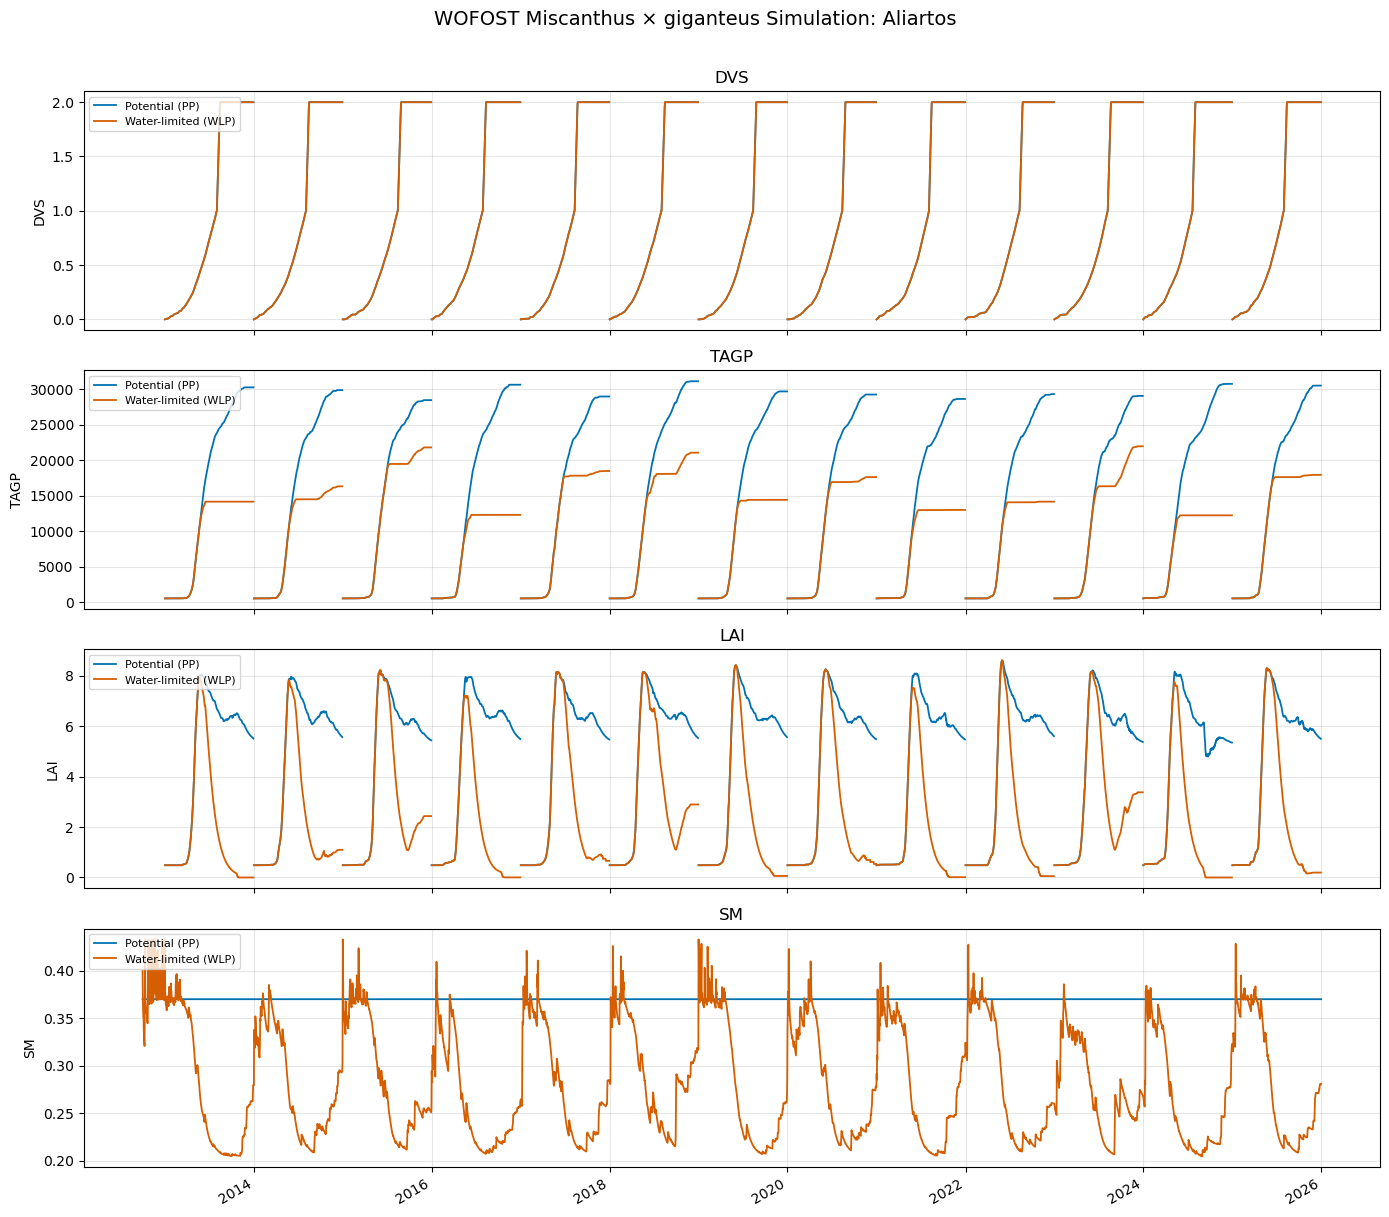

 Year   PP_t_ha  WLP_t_ha  Yield_gap_t_ha
 2012       NaN       NaN             NaN
 2013 30.245877 14.154985       16.090893
 2014 29.857254 16.313225       13.544029
 2015 28.447488 21.788493        6.658996
 2016 30.614184 12.299735       18.314449
 2017 28.956378 18.470745       10.485633
 2018 31.100889 21.050888       10.050001
 2019 29.672071 14.412674       15.259397
 2020 29.231995 17.615693       11.616302
 2021 28.612289 12.991471       15.620818
 2022 29.292148 14.156149       15.135999
 2023 29.039908 21.948813        7.091095
 2024 30.736399 12.230577       18.505822
 2025 30.492930 17.931475       12.561455
 SeasonYear  ObservedYear  Obs_rainfed  WLP_t_ha  Error_WLP  Obs_100PET  PP_t_ha  Error_PP
       2012          2013        13.38       NaN        NaN       23.29      NaN       NaN
       2013          2014        10.83     14.15       3.33       24.48    30.25      5.76
       2014          2015        11.41     16.31       4.90       23.06    29.86      6.79
      

In [4]:
# Import simulation engines
from matplotlib.pyplot import plot
from pcse.models import Wofost72_WLP_CWB, Wofost72_PP, Wofost81_WLP_CWB, Wofost81_PP

# Colors
PP_COLOR  = "#0072B2"
WLP_COLOR = "#D55E00"
OBS_COLOR = "#000000"

# Potential Production (PP)
wofsim_pp = Wofost72_PP(parameters, weatherdata, agromanagement)
wofsim_pp.run_till_terminate()
df_pp = pd.DataFrame(wofsim_pp.get_output()).set_index("day")

# Water-Limited Production (WLP)
wofsim_wlp = Wofost72_WLP_CWB(parameters, weatherdata, agromanagement)
wofsim_wlp.run_till_terminate()
df_wlp = pd.DataFrame(wofsim_wlp.get_output()).set_index("day")

print(f"PP  simulation: {df_pp.index[0]} to {df_pp.index[-1]}  ({len(df_pp)} days)")
print(f"WLP simulation: {df_wlp.index[0]} to {df_wlp.index[-1]}  ({len(df_wlp)} days)")


# Visualize results (both runs)
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)

for var, ax in zip(["DVS", "TAGP", "LAI", "SM"], axes.flatten()):
    ax.plot(df_pp.index, df_pp[var], color=PP_COLOR, linewidth=1.3, label="Potential (PP)")
    ax.plot(df_wlp.index, df_wlp[var], color=WLP_COLOR, linewidth=1.3, label="Water-limited (WLP)")
    ax.set_ylabel(var)
    ax.set_title(var)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)

fig.suptitle("WOFOST Miscanthus × giganteus Simulation: Aliartos", fontsize=14, y=1.01)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


# Quick yield summary per year (both runs)
df_pp["year"] = df_pp.index.map(lambda d: d.year)
df_wlp["year"] = df_wlp.index.map(lambda d: d.year)

yield_pp = df_pp.groupby("year")["TAGP"].max().reset_index()
yield_pp.columns = ["Year", "PP_TAGP_kg_ha"]
yield_pp["PP_t_ha"] = yield_pp["PP_TAGP_kg_ha"] / 1000

yield_wlp = df_wlp.groupby("year")["TAGP"].max().reset_index()
yield_wlp.columns = ["Year", "WLP_TAGP_kg_ha"]
yield_wlp["WLP_t_ha"] = yield_wlp["WLP_TAGP_kg_ha"] / 1000

yield_summary = yield_pp[["Year", "PP_t_ha"]].merge(yield_wlp[["Year", "WLP_t_ha"]], on="Year")
yield_summary["Yield_gap_t_ha"] = yield_summary["PP_t_ha"] - yield_summary["WLP_t_ha"]

print(yield_summary.to_string(index=False))


# === Comparison with Aliartos observations ===
# Aliartos is an irrigation gradient, so bracket the two sim scenarios with the end treatments:
#   WLP (rainfed sim)      <-> Irrigation 0  (rainfed observations)
#   PP  (well-watered sim) <-> Irrigation 3  (100% PET observations)
obs = pd.read_csv(input_dir / "aliartos_observations.csv", sep=";")  

# Mean observed DMY (total dry biomass = TAGP analogue) per year x irrigation, over the 6 reps
obs_year_irr = obs.groupby(["cal_year", "irrigation"])["DMY"].agg(["mean", "std"]).reset_index()
obs_rainfed  = obs_year_irr[obs_year_irr["irrigation"] == 0]
obs_full     = obs_year_irr[obs_year_irr["irrigation"] == 3]

#comparison = yield_summary.merge(
    #obs_rainfed[["cal_year", "mean", "std"]].rename(
        #columns={"cal_year": "Year", "mean": "Obs_rainfed", "std": "Obs_rainfed_sd"}), on="Year", how="inner")
#comparison = comparison.merge(
    #obs_full[["cal_year", "mean"]].rename(
        #columns={"cal_year": "Year", "mean": "Obs_100PET"}), on="Year", how="inner")

# Shift the simulated season year to the observed/harvest year label.
# Example: simulated 2025 growing season -> observed/harvest year 2026.
yield_summary["SeasonYear"] = yield_summary["Year"]
yield_summary["ObservedYear"] = yield_summary["SeasonYear"] + 1

comparison = yield_summary.merge(
    obs_rainfed[["cal_year", "mean", "std"]].rename(
        columns={"cal_year": "ObservedYear", "mean": "Obs_rainfed", "std": "Obs_rainfed_sd"}),
    on="ObservedYear", how="inner"
)
comparison = comparison.merge(
    obs_full[["cal_year", "mean"]].rename(
        columns={"cal_year": "ObservedYear", "mean": "Obs_100PET"}),
    on="ObservedYear", how="inner"
)

comparison["Error_WLP"] = comparison["WLP_t_ha"] - comparison["Obs_rainfed"]
comparison["Error_PP"]  = comparison["PP_t_ha"]  - comparison["Obs_100PET"]

def _gof(e):
    return np.sqrt((e ** 2).mean()), e.abs().mean(), e.mean()

rmse_wlp, mae_wlp, bias_wlp = _gof(comparison["Error_WLP"])
rmse_pp,  mae_pp,  bias_pp  = _gof(comparison["Error_PP"])

#print(comparison[["Year", "Obs_rainfed", "WLP_t_ha", "Error_WLP",
                  #"Obs_100PET", "PP_t_ha", "Error_PP"]].round(2).to_string(index=False))
print(comparison[["SeasonYear", "ObservedYear", "Obs_rainfed", "WLP_t_ha", "Error_WLP",
                  "Obs_100PET", "PP_t_ha", "Error_PP"]].round(2).to_string(index=False))

print(f"--- WLP vs rainfed (Irr 0) ---  RMSE {rmse_wlp:.2f} t/ha   MAE {mae_wlp:.2f}   Bias {bias_wlp:+.2f}")
print(f"--- PP  vs 100% PET (Irr 3) --- RMSE {rmse_pp:.2f} t/ha   MAE {mae_pp:.2f}   Bias {bias_pp:+.2f}")

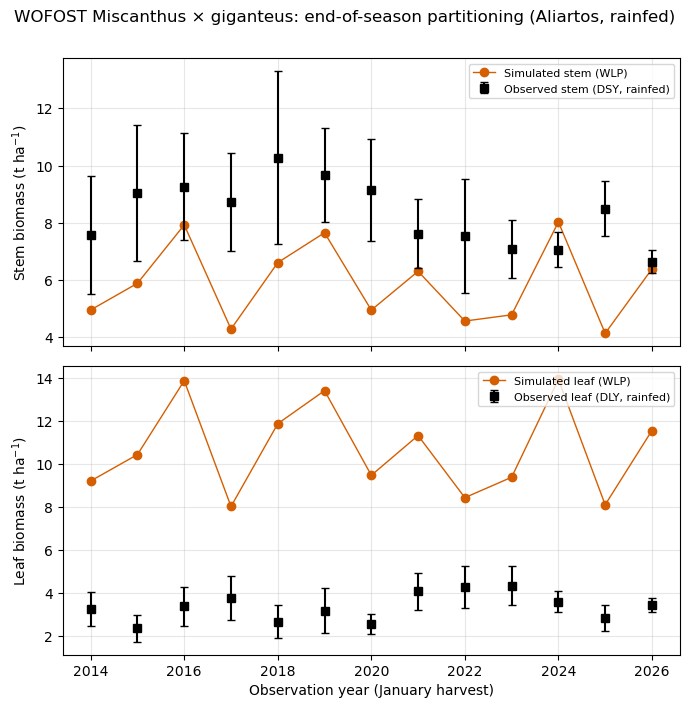

In [5]:
# === End-of-season partitioning: simulated (WLP) vs observed rainfed ===
obs = pd.read_csv(input_dir / "aliartos_observations.csv", sep=";")

def end_of_season(df):
    d = df.dropna(subset=["TAGP"]).copy()     # drop bare-soil spin-up days (all-NaN TAGP)
    d["year"] = d.index.map(lambda x: x.year)
    rows = d.loc[d.groupby("year")["TAGP"].idxmax()]
    out = pd.DataFrame({"Year": rows["year"].values,
        "stem_sim": (rows["TAGP"] - rows["TWLV"]).values / 1000,  # storage-organ pool folded into stem
        "leaf_sim":  rows["TWLV"].values / 1000,
        "tagp_sim":  rows["TAGP"].values / 1000})
    out = out[out["tagp_sim"] > 1].copy()                         # drop the spin-up year
    out["stemfrac_sim"] = out["stem_sim"] / out["tagp_sim"]
    out["ObservedYear"] = out["Year"] + 1                         # harvest-year alignment
    return out

sim_eos = end_of_season(df_wlp)
obs0 = obs[obs["irrigation"] == 0]
obs_eos = (obs0.groupby("cal_year")
              .agg(DSY=("DSY","mean"), DSY_sd=("DSY","std"),
                   DLY=("DLY","mean"), DLY_sd=("DLY","std"), DMY=("DMY","mean"))
              .reset_index().rename(columns={"cal_year": "ObservedYear"}))
obs_eos["stemfrac_obs"] = obs_eos["DSY"] / obs_eos["DMY"]

m = sim_eos.merge(obs_eos, on="ObservedYear", how="inner")
yrs = m["ObservedYear"]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 7), sharex=True)
axes[0].plot(yrs, m["stem_sim"], "-o", color=WLP_COLOR, lw=1, label="Simulated stem (WLP)")
axes[0].errorbar(yrs, m["DSY"], yerr=m["DSY_sd"], fmt="s", color=OBS_COLOR, capsize=3,
                 label="Observed stem (DSY, rainfed)")
axes[0].set_ylabel("Stem biomass (t ha$^{-1}$)")
axes[1].plot(yrs, m["leaf_sim"], "-o", color=WLP_COLOR, lw=1, label="Simulated leaf (WLP)")
axes[1].errorbar(yrs, m["DLY"], yerr=m["DLY_sd"], fmt="s", color=OBS_COLOR, capsize=3,
                 label="Observed leaf (DLY, rainfed)")
axes[1].set_ylabel("Leaf biomass (t ha$^{-1}$)")
for ax in axes:
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8, loc="best")
axes[1].set_xlabel("Observation year (January harvest)")
fig.suptitle("WOFOST Miscanthus × giganteus: end-of-season partitioning (Aliartos, rainfed)", y=1.005)
fig.tight_layout()
fig.savefig("aliartos_partitioning.pdf", bbox_inches="tight")
plt.show()

In [6]:
# === Goodness-of-fit: end-of-season partitioning (WLP sim vs rainfed obs) ===
# Same _gof helper as the yield cell; uses the paired frame `m` built above.
def _gof(e):
    return np.sqrt((e ** 2).mean()), e.abs().mean(), e.mean()

gof_eos = pd.DataFrame(
    [("Stem (DSY)",  *_gof(m["stem_sim"] - m["DSY"])),
     ("Leaf (DLY)",  *_gof(m["leaf_sim"] - m["DLY"])),
     ("Total (DMY)", *_gof(m["tagp_sim"] - m["DMY"]))],
    columns=["Component", "RMSE", "MAE", "Bias"])
gof_eos["n"] = len(m)

print(gof_eos.round(2).to_string(index=False))
print("(RMSE, MAE, Bias in t/ha)")

# Partitioning ratio (dimensionless stem fraction)
sf = m["stemfrac_sim"] - m["stemfrac_obs"]
print(f"Stem fraction    MAE {sf.abs().mean():.3f}    Bias {sf.mean():+.3f}")

  Component  RMSE  MAE  Bias  n
 Stem (DSY)  2.91 2.59 -2.44 13
 Leaf (DLY)  7.64 7.32  7.32 13
Total (DMY)  5.93 4.90  4.87 13
(RMSE, MAE, Bias in t/ha)
Stem fraction    MAE 0.356    Bias -0.356


 SeasonYear  ObservedYear  Obs_rainfed  WLP_t_ha  Error_WLP  Obs_100PET  PP_t_ha  Error_PP
       2013          2014        10.83     14.15       3.33       24.48    30.25      5.76
       2014          2015        11.41     16.31       4.90       23.06    29.86      6.79
       2015          2016        12.65     21.79       9.14       21.95    28.45      6.50
       2016          2017        12.50     12.30      -0.20       20.66    30.61      9.95
       2017          2018        12.97     18.47       5.50       19.48    28.96      9.48
       2018          2019        12.87     21.05       8.18       20.23    31.10     10.87
       2019          2020        11.73     14.41       2.69       18.53    29.67     11.15
       2020          2021        11.71     17.62       5.91       17.96    29.23     11.27
       2021          2022        11.83     12.99       1.17       19.23    28.61      9.38
       2022          2023        11.44     14.16       2.72       16.92    29.29     12.37

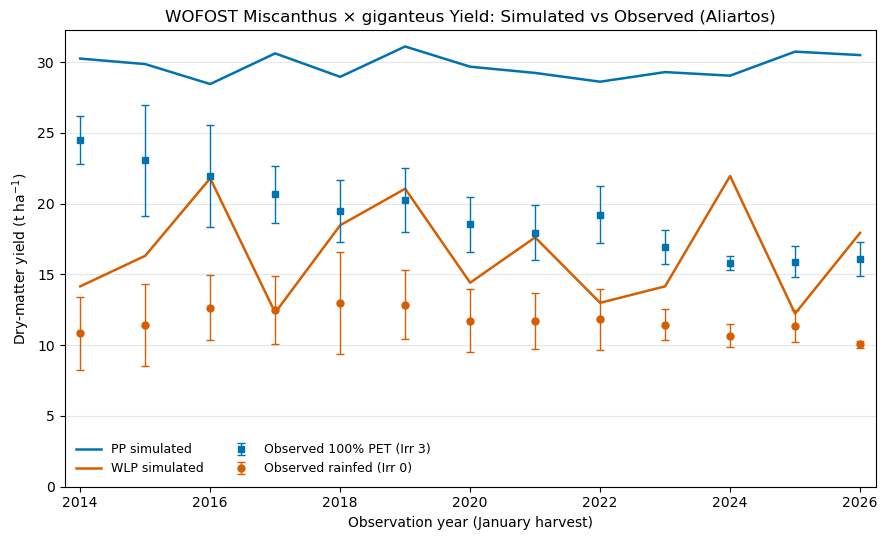

In [7]:
# === Comparison with Aliartos observations ===
# WLP (rainfed sim) vs Irrigation 0 ; PP (well-watered sim) vs Irrigation 3.
obs = pd.read_csv(input_dir / "aliartos_observations.csv", sep=";")

# Mean and SD of observed DMY per year x irrigation, over the replicate plots (3 blocks x 2 densities)
obs_year_irr = obs.groupby(["cal_year", "irrigation"])["DMY"].agg(["mean", "std"]).reset_index()
obs_rainfed = obs_year_irr[obs_year_irr["irrigation"] == 0].rename(
    columns={"cal_year": "ObservedYear", "mean": "Obs_rainfed", "std": "Obs_rainfed_sd"})
obs_full = obs_year_irr[obs_year_irr["irrigation"] == 3].rename(
    columns={"cal_year": "ObservedYear", "mean": "Obs_100PET", "std": "Obs_100PET_sd"})

# Drop the 2012 spin-up year (no crop -> NaN), then shift the simulated growing-season year
# to the observed January-harvest year (e.g. 2025 season -> observed 2026)
yield_summary = yield_summary.dropna(subset=["PP_t_ha", "WLP_t_ha"]).reset_index(drop=True)
yield_summary["SeasonYear"]   = yield_summary["Year"]
yield_summary["ObservedYear"] = yield_summary["SeasonYear"] + 1

comparison = (yield_summary
    .merge(obs_rainfed[["ObservedYear", "Obs_rainfed", "Obs_rainfed_sd"]], on="ObservedYear", how="inner")
    .merge(obs_full[["ObservedYear", "Obs_100PET", "Obs_100PET_sd"]], on="ObservedYear", how="inner"))

comparison["Error_WLP"] = comparison["WLP_t_ha"] - comparison["Obs_rainfed"]
comparison["Error_PP"]  = comparison["PP_t_ha"]  - comparison["Obs_100PET"]

def _gof(e):
    return np.sqrt((e ** 2).mean()), e.abs().mean(), e.mean()

rmse_wlp, mae_wlp, bias_wlp = _gof(comparison["Error_WLP"])
rmse_pp,  mae_pp,  bias_pp  = _gof(comparison["Error_PP"])

print(comparison[["SeasonYear", "ObservedYear", "Obs_rainfed", "WLP_t_ha", "Error_WLP",
                  "Obs_100PET", "PP_t_ha", "Error_PP"]].round(2).to_string(index=False))
print(f"--- WLP vs rainfed (Irr 0) ---  RMSE {rmse_wlp:.2f} t/ha   MAE {mae_wlp:.2f}   Bias {bias_wlp:+.2f}")
print(f"--- PP  vs 100% PET (Irr 3) --- RMSE {rmse_pp:.2f} t/ha   MAE {mae_pp:.2f}   Bias {bias_pp:+.2f}")


# === Plot: simulated lines vs observed means with SD whiskers, paired by water regime ===
fig, ax = plt.subplots(figsize=(9, 5.5))
yrs = comparison["ObservedYear"]

# Potential / 100% PET (blue)
ax.plot(yrs, comparison["PP_t_ha"], color=PP_COLOR, lw=1.8, zorder=2, label="PP simulated")
ax.errorbar(yrs, comparison["Obs_100PET"], yerr=comparison["Obs_100PET_sd"],
            fmt="s", color=PP_COLOR, ms=5, capsize=3, lw=1, zorder=3, label="Observed 100% PET (Irr 3)")

# Water-limited / rainfed (orange)
ax.plot(yrs, comparison["WLP_t_ha"], color=WLP_COLOR, lw=1.8, zorder=2, label="WLP simulated")
ax.errorbar(yrs, comparison["Obs_rainfed"], yerr=comparison["Obs_rainfed_sd"],
            fmt="o", color=WLP_COLOR, ms=5, capsize=3, lw=1, zorder=3, label="Observed rainfed (Irr 0)")

ax.set_xlabel("Observation year (January harvest)")
ax.set_ylabel("Dry-matter yield (t ha$^{-1}$)")
ax.set_ylim(bottom=0)
ax.margins(x=0.02)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(frameon=False, ncol=2, fontsize=9, loc="lower left")
ax.set_title("WOFOST Miscanthus × giganteus Yield: Simulated vs Observed (Aliartos)")
fig.tight_layout()
fig.savefig("aliartos_sim_vs_obs.pdf", bbox_inches="tight")
plt.show()

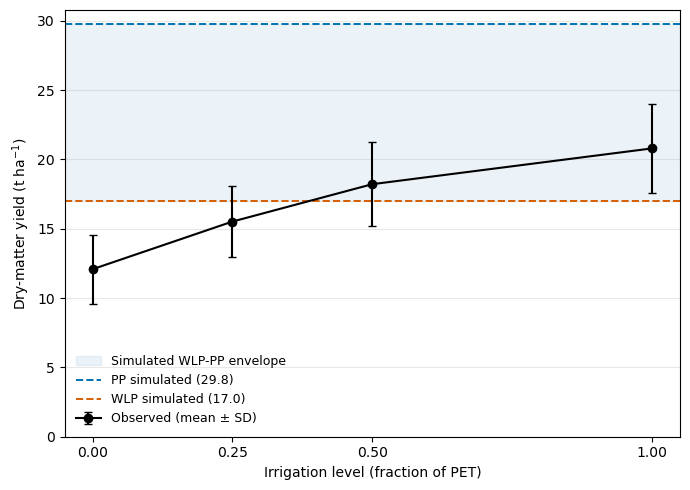

In [8]:
# === Observed dose-response vs simulated PP-WLP envelope ===
pet_frac = {0: 0.0, 1: 0.25, 2: 0.5, 3: 1.0}

mid = obs[obs["cal_year"].between(2014, 2021)]                       # mid-life window
dose = mid.groupby("irrigation")["DMY"].agg(["mean", "std"]).reset_index()
dose["frac"] = dose["irrigation"].map(pet_frac)

window  = comparison[comparison["ObservedYear"].between(2014, 2021)]
pp_mean, wlp_mean = window["PP_t_ha"].mean(), window["WLP_t_ha"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.axhspan(wlp_mean, pp_mean, color=PP_COLOR, alpha=0.08, label="Simulated WLP-PP envelope")
ax.axhline(pp_mean,  color=PP_COLOR,  lw=1.4, ls="--", label=f"PP simulated ({pp_mean:.1f})")
ax.axhline(wlp_mean, color=WLP_COLOR, lw=1.4, ls="--", label=f"WLP simulated ({wlp_mean:.1f})")
ax.errorbar(dose["frac"], dose["mean"], yerr=dose["std"],
            fmt="o-", color="#000000", capsize=3, ms=6, label="Observed (mean ± SD)")
ax.set_xlabel("Irrigation level (fraction of PET)")
ax.set_ylabel("Dry-matter yield (t ha$^{-1}$)")
ax.set_xticks(list(pet_frac.values()))
ax.set_ylim(bottom=0)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig("aliartos_dose_response.pdf", bbox_inches="tight")
plt.show()